# Data Quality Control Report
## Project: Diabetes Health Indicators Predictive Analysis
---

## 1. Environment Setup
Loading essential libraries for data validation and visualization.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Configuration
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

# Output directory for figures
OUTPUT_FIG_PATH = "D:/MACHINE_LERNING_PROJECTS/DATA_diabetes_012_health_indicators/outputs/quality_fig"

## 2. Data Ingestion
Loading the dataset from the `db/` directory.

In [40]:
DATA_PATH = '../db/diabetes_012_health_indicators_BRFSS2015.csv'

if not os.path.exists(DATA_PATH):
    print(f'Error: Data file not found at {DATA_PATH}')
else:
    df = pd.read_csv(DATA_PATH)
    print(f'Dataset loaded successfully. Shape: {df.shape}')
    display(df.head())

Dataset loaded successfully. Shape: (253680, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## 3. Structural Quality Check
Validating data types and memory footprint.

In [29]:
print('--- Data Types ---')
print(df.dtypes)

print('\n--- Memory Usage ---')
print(df.info(memory_usage='deep'))

--- Data Types ---
Diabetes_012            float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object

--- Memory Usage ---
<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non

## 4. Completeness Analysis
Checking for missing values across all features.

In [41]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

qc_completeness = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percent
}).sort_values(by='Percentage (%)', ascending=False)

display(qc_completeness)

# Visualization
if missing_values.sum() > 0:
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.savefig(f"{OUTPUT_FIG_PATH}/missing_values.png", dpi=300, bbox_inches='tight')
    plt.show()
else:
    print('No missing values detected.')

,Missing Values,Percentage (%)
Diabetes_012,0,0.0
HighBP,0,0.0
HighChol,0,0.0
CholCheck,0,0.0
BMI,0,0.0
Smoker,0,0.0
Stroke,0,0.0
HeartDiseaseorAttack,0,0.0
PhysActivity,0,0.0
Fruits,0,0.0


No missing values detected.


## 5. Uniqueness Analysis
Identifying duplicate records in the dataset.

In [13]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')
print(f'Percentage of duplicates: {(duplicates / len(df)) * 100:.2f}%')

if duplicates > 0:
    print('Warning: Duplicate rows found. Consider investigating if these are valid observations.')

Number of duplicate rows: 23899
Percentage of duplicates: 9.42%


## 6. Validity & Constraint Checks
Ensuring values fall within expected ranges and categories.

In [14]:
# Binary Columns Validation
binary_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 
               'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 
               'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']

print('--- Binary Consistency Check (Should only be 0 or 1) ---')
for col in binary_cols:
    unique_vals = sorted(df[col].unique())
    status = 'Ok' if set(unique_vals).issubset({0, 1}) else 'False'
    print(f'{col}: {unique_vals} {status}')

# Target Variable Check
print('\n--- Target Variable (Diabetes_012) ---')
print(df['Diabetes_012'].value_counts(normalize=True) * 100)

--- Binary Consistency Check (Should only be 0 or 1) ---
HighBP: [np.float64(0.0), np.float64(1.0)] Ok
HighChol: [np.float64(0.0), np.float64(1.0)] Ok
CholCheck: [np.float64(0.0), np.float64(1.0)] Ok
Smoker: [np.float64(0.0), np.float64(1.0)] Ok
Stroke: [np.float64(0.0), np.float64(1.0)] Ok
HeartDiseaseorAttack: [np.float64(0.0), np.float64(1.0)] Ok
PhysActivity: [np.float64(0.0), np.float64(1.0)] Ok
Fruits: [np.float64(0.0), np.float64(1.0)] Ok
Veggies: [np.float64(0.0), np.float64(1.0)] Ok
HvyAlcoholConsump: [np.float64(0.0), np.float64(1.0)] Ok
AnyHealthcare: [np.float64(0.0), np.float64(1.0)] Ok
NoDocbcCost: [np.float64(0.0), np.float64(1.0)] Ok
DiffWalk: [np.float64(0.0), np.float64(1.0)] Ok
Sex: [np.float64(0.0), np.float64(1.0)] Ok

--- Target Variable (Diabetes_012) ---
Diabetes_012
0.0    84.241170
2.0    13.933302
1.0     1.825528
Name: proportion, dtype: float64


## 7. Statistical Profiling & Outliers
Analyzing distributions and identifying extreme values.

,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


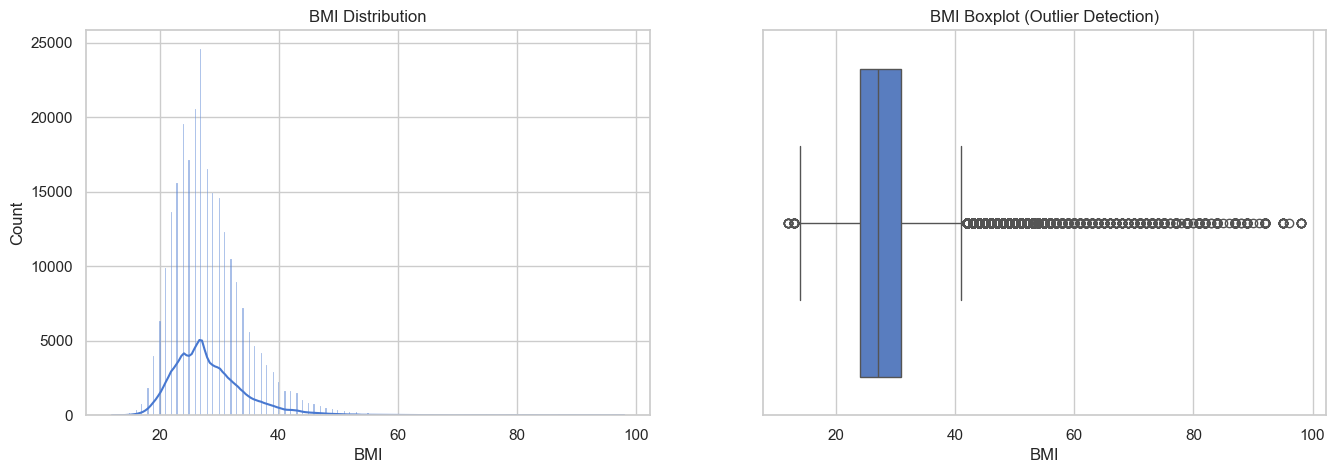

In [17]:
display(df.describe().T)

# BMI Distribution & Outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(df['BMI'], kde=True, ax=axes[0])
axes[0].set_title('BMI Distribution')
sns.boxplot(x=df['BMI'], ax=axes[1])
axes[1].set_title('BMI Boxplot (Outlier Detection)')
plt.savefig(os.path.join(OUTPUT_FIG_PATH, 'bmi_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

## 8. Correlation Analysis
Checking for redundant features and initial insights.

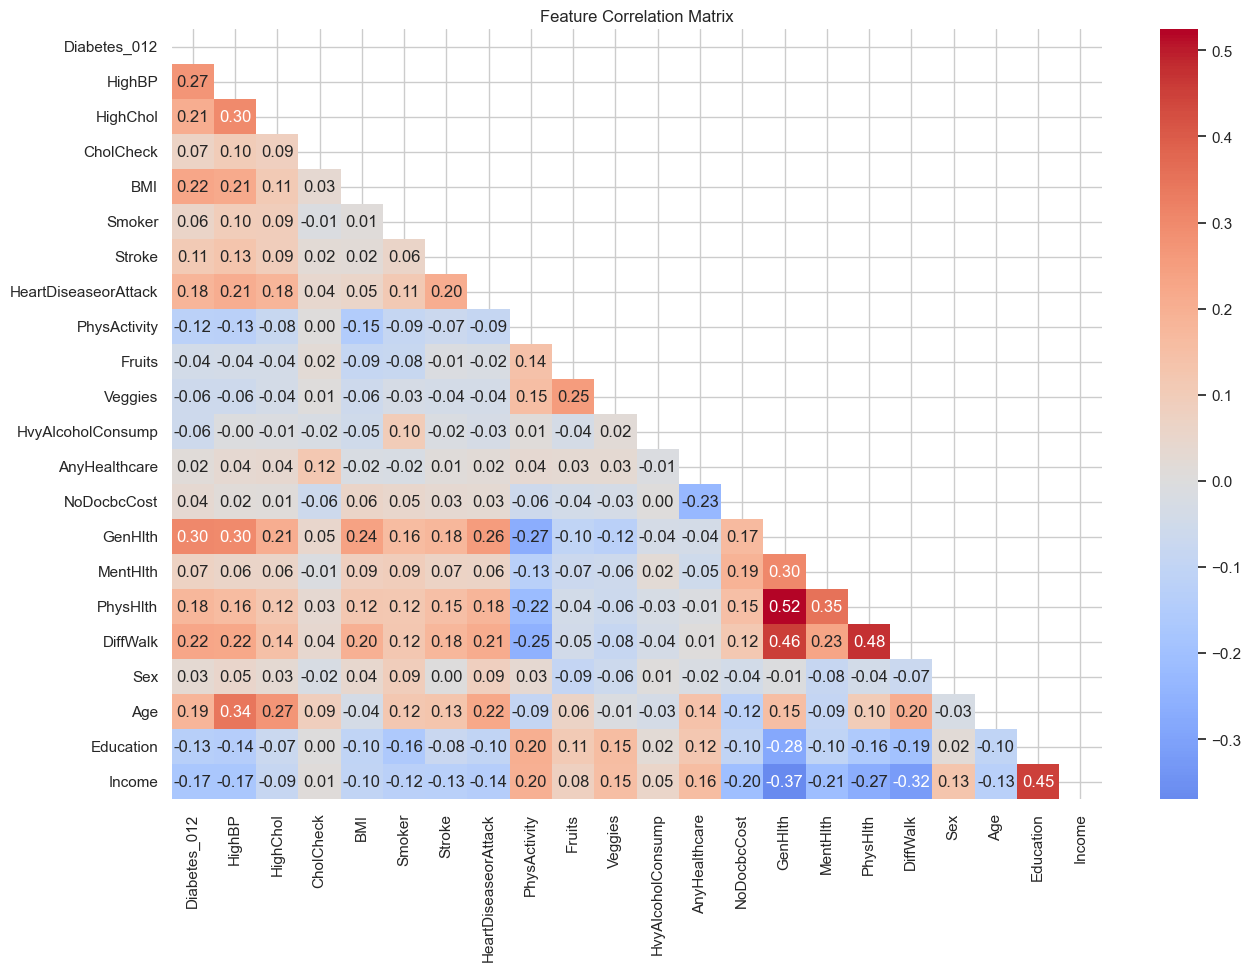

In [16]:
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.savefig(os.path.join(OUTPUT_FIG_PATH, 'correlation_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()